In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
     

In [3]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.719289,0.957879,-0.516383,-4.361262,2.458029,1
1,0.299775,2.673124,-1.607872,0.724870,-0.817963,0
2,-0.411529,1.836862,0.299719,-0.265642,-0.970035,0
3,-2.144805,2.781811,3.545349,-2.128415,-0.579381,1
4,-1.681923,1.027793,0.471082,0.697511,2.215729,0


In [4]:

# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [8]:

# function for feature sampling
import random
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [9]:

# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [10]:

df1 = combined_sampling(df,0.5,0.5)

/var/folders/bl/wwtw75nn47120mwmkrc271m00000gn/T/ipykernel_96533/3764219156.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [11]:
df2 = combined_sampling(df,0.5,0.5)

/var/folders/bl/wwtw75nn47120mwmkrc271m00000gn/T/ipykernel_96533/3764219156.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [12]:

df3 = combined_sampling(df,0.5,0.5)

/var/folders/bl/wwtw75nn47120mwmkrc271m00000gn/T/ipykernel_96533/3764219156.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [20]:
df3

,col1,col3,target
0,-0.719289,-0.516383,1
30,-1.452937,1.045555,0
80,-0.628139,-1.183375,0
99,-1.095042,0.277113,1
6,-0.450607,0.223125,0
75,-2.156232,1.575916,1
50,-0.218158,-3.376635,0
46,-0.270470,-2.174022,0
9,-1.972172,-1.792874,0
60,-1.682115,1.246173,1


In [13]:

print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col4', 'target'], dtype='object')
Index(['col1', 'col4', 'target'], dtype='object')
Index(['col1', 'col3', 'target'], dtype='object')


In [14]:

from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [15]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.5, 0.9166666666666666, 'x[1] <= 0.148\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.4, 0.75, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.45, 0.8333333333333333, 'True  '),
 Text(0.6, 0.75, 'x[0] <= 1.198\ngini = 0.375\nsamples = 36\nvalue = [27, 9]'),
 Text(0.55, 0.8333333333333333, '  False'),
 Text(0.4, 0.5833333333333334, 'x[1] <= 1.721\ngini = 0.185\nsamples = 29\nvalue = [26, 3]'),
 Text(0.3, 0.4166666666666667, 'x[1] <= 0.744\ngini = 0.133\nsamples = 28\nvalue = [26, 2]'),
 Text(0.2, 0.25, 'x[1] <= 0.733\ngini = 0.278\nsamples = 12\nvalue = [10, 2]'),
 Text(0.1, 0.08333333333333333, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.3, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.4, 0.25, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.5, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5833333333333334, 'x[1] <= 0.604\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.7, 0.4166666666

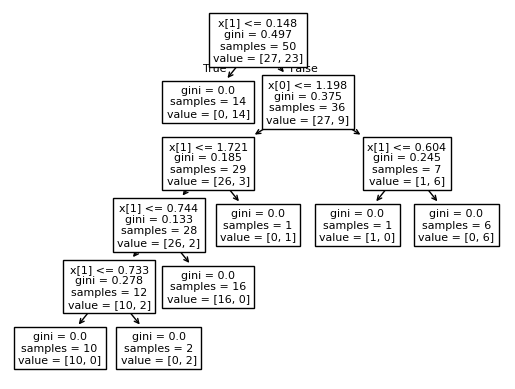

In [17]:


plot_tree(clf1)

[Text(0.4090909090909091, 0.9285714285714286, 'x[1] <= 0.161\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.3181818181818182, 0.7857142857142857, 'gini = 0.0\nsamples = 21\nvalue = [0, 21]'),
 Text(0.36363636363636365, 0.8571428571428572, 'True  '),
 Text(0.5, 0.7857142857142857, 'x[1] <= 1.375\ngini = 0.4\nsamples = 29\nvalue = [21, 8]'),
 Text(0.4545454545454546, 0.8571428571428572, '  False'),
 Text(0.2727272727272727, 0.6428571428571429, 'x[0] <= -3.484\ngini = 0.308\nsamples = 21\nvalue = [17, 4]'),
 Text(0.18181818181818182, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.36363636363636365, 0.5, 'x[0] <= -0.029\ngini = 0.255\nsamples = 20\nvalue = [17, 3]'),
 Text(0.18181818181818182, 0.35714285714285715, 'x[1] <= 1.201\ngini = 0.117\nsamples = 16\nvalue = [15, 1]'),
 Text(0.09090909090909091, 0.21428571428571427, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.2727272727272727, 0.21428571428571427, 'x[1] <= 1.241\ngini = 0.375\nsamples = 4\nvalue = [

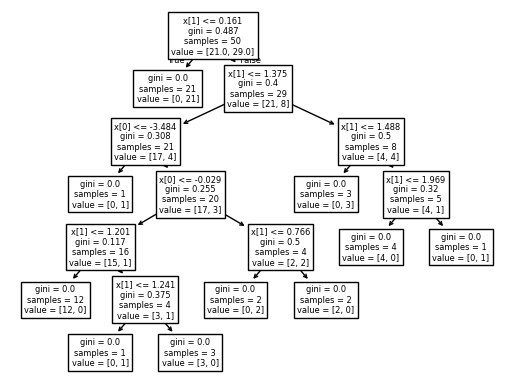

In [18]:
plot_tree(clf2)

[Text(0.4444444444444444, 0.9375, 'x[1] <= -0.748\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.2222222222222222, 0.8125, 'x[0] <= 0.331\ngini = 0.1\nsamples = 19\nvalue = [18, 1]'),
 Text(0.3333333333333333, 0.875, 'True  '),
 Text(0.1111111111111111, 0.6875, 'gini = 0.0\nsamples = 18\nvalue = [18, 0]'),
 Text(0.3333333333333333, 0.6875, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.8125, 'x[1] <= 1.146\ngini = 0.35\nsamples = 31\nvalue = [7, 24]'),
 Text(0.5555555555555556, 0.875, '  False'),
 Text(0.5555555555555556, 0.6875, 'x[1] <= 0.033\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.4444444444444444, 0.5625, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.6666666666666666, 0.5625, 'x[1] <= 0.25\ngini = 0.497\nsamples = 13\nvalue = [7, 6]'),
 Text(0.5555555555555556, 0.4375, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.7777777777777778, 0.4375, 'x[1] <= 0.886\ngini = 0.444\nsamples = 9\nvalue = [3, 6]'),
 Text(0.66666666666666

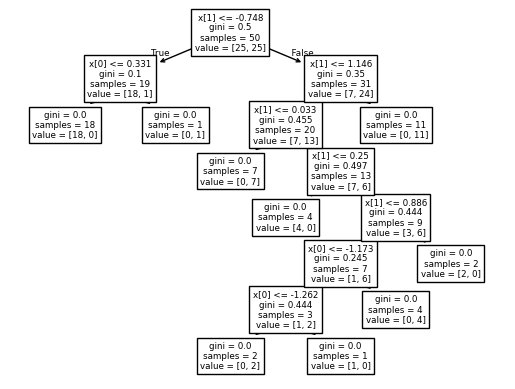

In [19]:
plot_tree(clf3)

In [24]:

clf1.predict(np.array([-0.719289, -0.516383]).reshape(1,2))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [25]:
clf2.predict(np.array([-0.719289, -0.516383]).reshape(1,2))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [26]:
clf3.predict(np.array([-0.719289, -0.516383]).reshape(1,2))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])